# HR Employee Attrition: Deep-Dive Analytics & Retention Strategy
**Author:** Yuvraj | **Tools:** Python, Pandas, Seaborn, Matplotlib, SciPy
**Dataset:** IBM HR Analytics (1,470 employees, 35 features)

## Business Problem
Why are employees leaving, which segments are at highest risk, and what should HR do about it?

## Table of Contents
1. Setup & Data Quality
2. Univariate & Segment Analysis
3. Statistical Testing
4. Key Findings & Recommendations

# Phase 1: Setup & Data Quality

## 1.1 Setup

In [1]:
# Importing libraries and setting a consistent visual theme for all charts"
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style='whitegrid',palette="Set2",font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

## 1.2 Loading the Data

In [2]:
#Load & first look
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f'\nRows-{df.shape[0]} , Columns-{df.shape[1]}\n')
df.head()


Rows-1470 , Columns-35



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
#checking for null values-- 
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
# checking for duplicated values --- 
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### **Observations**
- Dataset has 1,470 rows × 35 columns
- No missing values and no duplicates, so no imputation needed
- Mix of numeric and categorical features

## 1.3 Removing zero-variance columns

In [7]:
df.nunique().sort_values().head()

EmployeeCount    1
Over18           1
StandardHours    1
Attrition        2
OverTime         2
dtype: int64

In [8]:
df['EmployeeCount'].value_counts()

EmployeeCount
1    1470
Name: count, dtype: int64

In [9]:
df['Over18'].value_counts()

Over18
Y    1470
Name: count, dtype: int64

In [10]:
df['StandardHours'].value_counts()

StandardHours
80    1470
Name: count, dtype: int64

We notice that 'EmployeeCount', 'Over18', 'StandardHours' have only one unique values and 'EmployeeNumber' has 1470 unique values. This features aren't useful for us, So we are going to drop those columns.

In [11]:
df.drop(columns=['EmployeeCount','Over18','StandardHours','EmployeeNumber'],inplace=True)
print(df.shape)

(1470, 31)


## 1.4 Map numeric-coded categoricals to labels

In [12]:
sat_map = {1: "Low", 2: "Medium", 3: "High", 4: "Very High"}

maps = {
    "Education": {1: "Below College", 2: "College", 3: "Bachelor", 4: "Master", 5: "Doctor"},
    "EnvironmentSatisfaction": sat_map,
    "JobSatisfaction": sat_map,
    "RelationshipSatisfaction": sat_map,
    "JobInvolvement": sat_map,
    "WorkLifeBalance": {1: "Bad", 2: "Good", 3: "Better", 4: "Best"},
    "PerformanceRating": {3: "Excellent", 4: "Outstanding"},
}

# keep numeric originals for correlation later, add readable versions
for col, m in maps.items():
    df[col + "_Label"] = df[col].map(m)

In [13]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Education_Label,EnvironmentSatisfaction_Label,JobSatisfaction_Label,RelationshipSatisfaction_Label,JobInvolvement_Label,WorkLifeBalance_Label,PerformanceRating_Label
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,College,Medium,Very High,Low,High,Bad,Excellent
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,Below College,High,Medium,Very High,Medium,Better,Outstanding
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,College,Very High,High,Medium,Medium,Better,Excellent
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,Master,Very High,High,High,High,Better,Excellent
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,Below College,Low,Medium,Very High,High,Better,Excellent


Several columns are stored as numbers (1-4) but represent ordered categories
Labels were added as new columns, so numeric versions remain available for correlation analysis

## 1.5 Class Imbalance Check

In [14]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [15]:
df["Attrition"].value_counts(normalize=True).round(3) * 100

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64

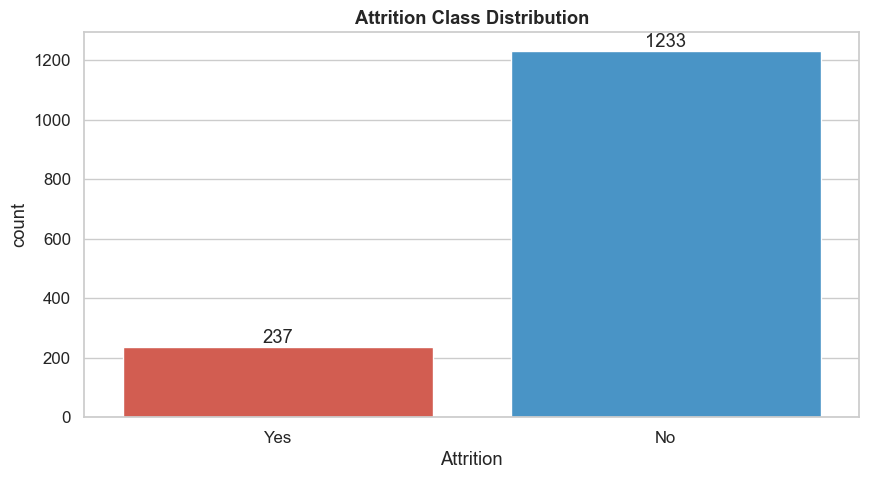

In [16]:
ax = sns.countplot(data=df, x="Attrition", palette={"Yes": "#E74C3C", "No": "#3498DB"})
ax.set_title("Attrition Class Distribution", fontweight="bold")

for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

### Class Imbalance Check
- **No: 1,233 (83.9%)** | **Yes: 237 (16.1%)**
- The dataset is imbalanced, so a model that always predicts "No" would be 84% accurate while catching zero leavers.
- **Implication:** Raw accuracy is misleading here. Any predictive modelling needs precision/recall/F1 and techniques like SMOTE or class weights. For this analysis, always compare **attrition rates (%)** within segments, not raw counts.

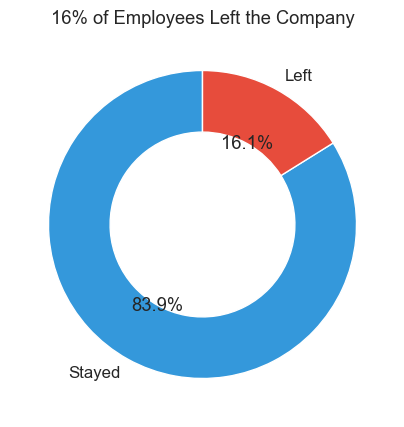

In [17]:
counts = df["Attrition"].value_counts()
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts, labels=["Stayed", "Left"], colors=["#3498DB", "#E74C3C"], autopct="%1.1f%%",
       startangle=90, wedgeprops={"width": 0.4, "edgecolor": "white"})
ax.set_title("16% of Employees Left the Company")
plt.show()

# Phase 2: Univariate & Segment Analysis

## 2.1 Overall Attrition Rate

In [18]:
df['Attrition_flag'] = (df['Attrition']=="Yes").astype('int')
overall_rate = df['Attrition_flag'].mean()*100
print(f'Overall attrition rate: {overall_rate:.1f}%')

Overall attrition rate: 16.1%


Overall attrition is **16.1%** (237 of 1,470 employees). This is the baseline every segment is compared against.

## 2.2 Segment Breakdown
Creating helper functions because we need same calculation (group → count → rate → chart) 6 times, for Department, JobRole, and so on. Instead of copy-pasting 6 times, we write it once as a function and reuse it.

In [19]:
def attrition_by(col,data=df,order=None):
    t = (data.groupby(col)['Attrition_flag'].agg(Employees='count',Leavers='sum',Rate='mean'))
    t['Rate']=(t['Rate']*100).round(2)
    return t.sort_values('Rate',ascending=False) if order is None else t.loc[order]

In [20]:
attrition_by('Department')

,Employees,Leavers,Rate
Department,,,
Sales,446,92,20.63
Human Resources,63,12,19.05
Research & Development,961,133,13.84


In [21]:
def plot_attrition_rate(col,data=df,order=None,title=None,rotate=0):
    t = attrition_by(col,data,order).reset_index()
    
    fig, axes = plt.subplots(figsize=(8,6))
    sns.barplot(data=t,x=col,y='Rate',order=order or t[col],color= '#3498DB',ax=axes) 
    axes.axhline(overall_rate,color="#E74C3C",ls='--',label=f'Overall:{overall_rate:.1f}%')

    for container in axes.containers:
        axes.bar_label(container)

    axes.set_title(title or f"Attrition Rate by {col}", fontweight="bold")
    axes.set_ylabel("Attrition Rate (%)")
    axes.legend()
    plt.xticks(rotation=rotate)
    plt.tight_layout()
    plt.show()

**A. Attrition by Department**

In [22]:
attrition_by(col='Department',data=df)

,Employees,Leavers,Rate
Department,,,
Sales,446,92,20.63
Human Resources,63,12,19.05
Research & Development,961,133,13.84


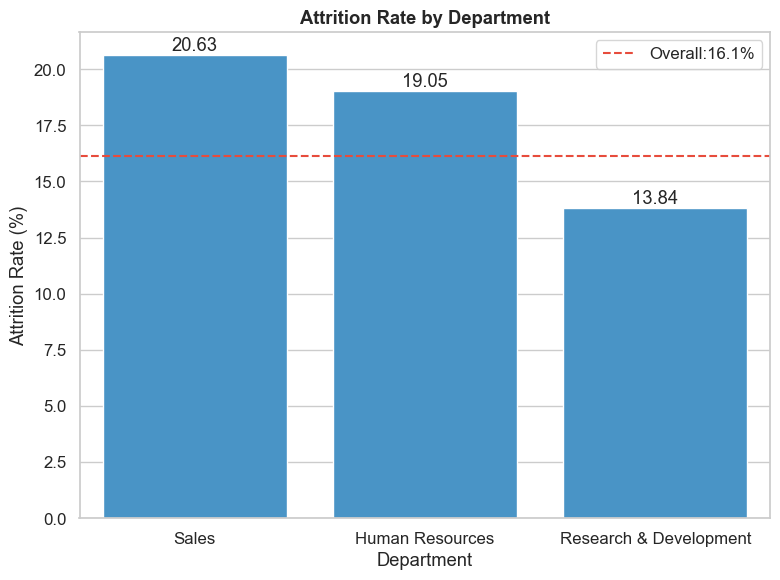

In [23]:
plot_attrition_rate(col='Department',data=df)

**Finding:** Sales has the highest departmental attrition (~21%), above the 16% baseline. Research & Development is the lowest.       
**Why it matters:** The department level hides role-level differences. Check Job Role next, because specific roles inside Sales may be driving this.

**B. Attrition by Job Role**

In [24]:
attrition_by('JobRole',df)

,Employees,Leavers,Rate
JobRole,,,
Sales Representative,83,33,39.76
Laboratory Technician,259,62,23.94
Human Resources,52,12,23.08
Sales Executive,326,57,17.48
Research Scientist,292,47,16.10
Manufacturing Director,145,10,6.90
Healthcare Representative,131,9,6.87
Manager,102,5,4.90
Research Director,80,2,2.50


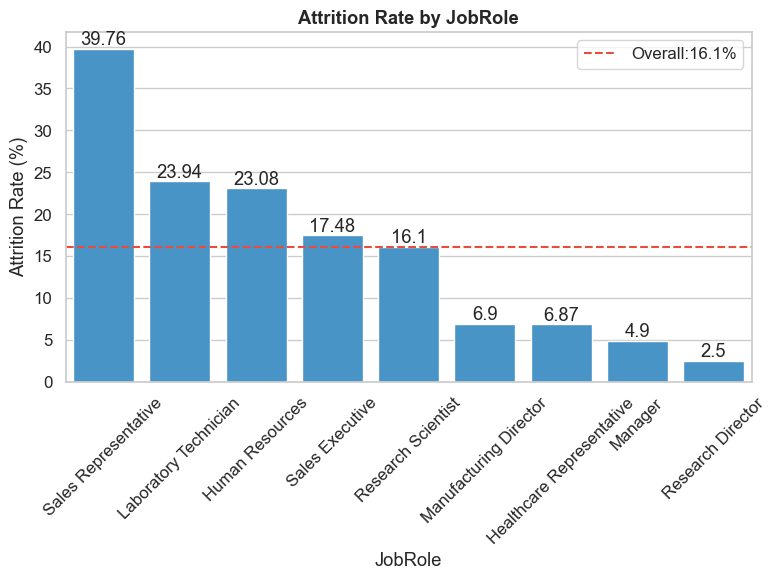

In [25]:
plot_attrition_rate('JobRole',df,rotate=45)

**Finding:** Sales Representatives have the highest attrition (~40%), far above the 16% baseline. 
Research Directors and  Manager are among lowest.                                            
**Why it matters:** Attrition is concentrated in specific roles, not spread evenly.

**C. Attrition by OverTime**

In [26]:
attrition_by('OverTime',df)

,Employees,Leavers,Rate
OverTime,,,
Yes,416,127,30.53
No,1054,110,10.44


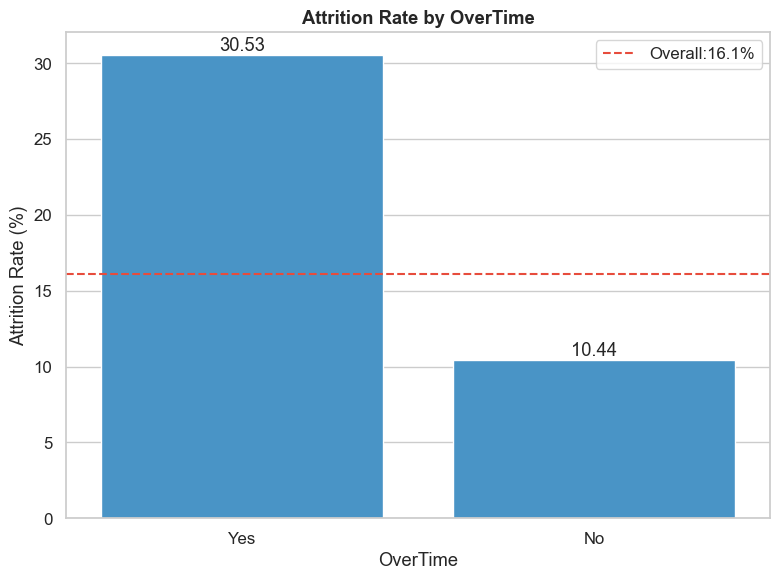

In [27]:
plot_attrition_rate('OverTime',df)

**Finding:** Employees working overtime leave at 30%, roughly 3x the rate of those who don't (10%) and far above the 16% baseline.                
**Why it matters:** This is the largest gap so far and it is an actionable factor, since workload is something HR can change.

**D. Attrition by Gender**

In [28]:
attrition_by('Gender',df)

,Employees,Leavers,Rate
Gender,,,
Male,882,150,17.01
Female,588,87,14.80


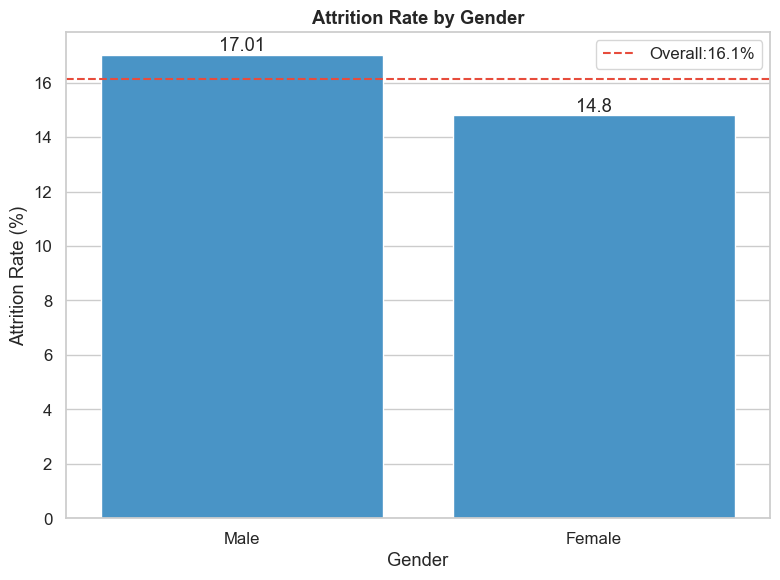

In [29]:
plot_attrition_rate('Gender',df)

**Finding:** Male attrition (~17%) is only slightly higher than female (14.8%). The gap is small and sits close to the 16% baseline.         
**Why it matters:** Gender does not look like a major driver of attrition.

**E. Attrition by Maritial Status**

In [30]:
attrition_by("MaritalStatus",df)

,Employees,Leavers,Rate
MaritalStatus,,,
Single,470,120,25.53
Married,673,84,12.48
Divorced,327,33,10.09


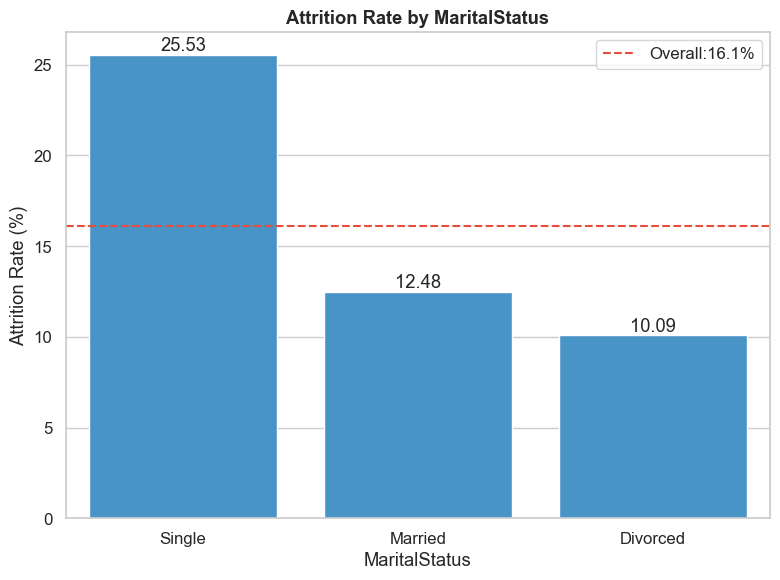

In [31]:
plot_attrition_rate('MaritalStatus',df)

**Finding:** Single employees have the highest attrition (~25%), while Married and Divorced employees are much lower.                  
**Why it matters:** Single employees are a higher-risk group. A possible explanation is that they have fewer ties to one location and so are more mobile, but this is a hypothesis, not proven. Age may also play a part.

**F. Attrition By Education Field**

In [32]:
attrition_by('EducationField',df)

,Employees,Leavers,Rate
EducationField,,,
Human Resources,27,7,25.93
Technical Degree,132,32,24.24
Marketing,159,35,22.01
Life Sciences,606,89,14.69
Medical,464,63,13.58
Other,82,11,13.41


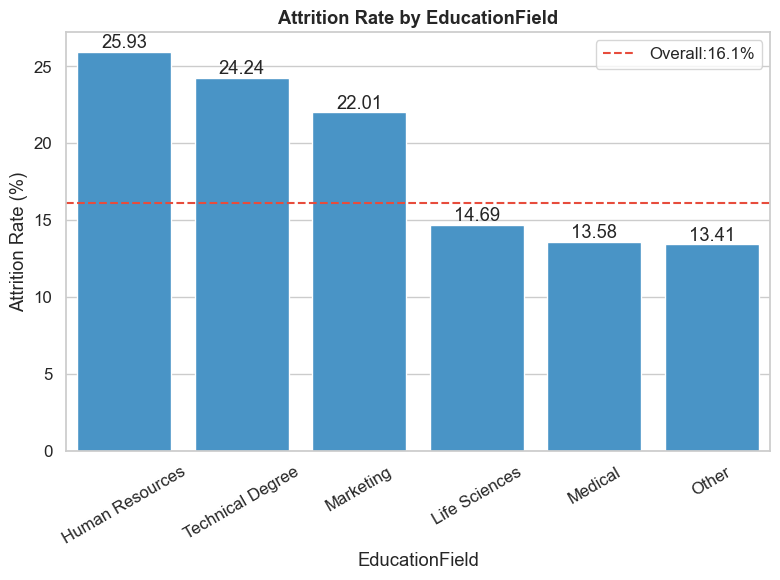

In [33]:
plot_attrition_rate('EducationField',df,rotate=30)

**Finding:** Human Resources, Technical Degree and Marketing show higher attrition (>22%), while Medical and Other are among the lowest.               
**Caution:** The Human Resources group is very small (~27 employees), so its rate is unreliable. Treat Technical Degree and Marketing as the more dependable signals.                                
**Why it matters:** The field of study may reflect job-market demand.

**Strongest signals (largest gap vs baseline):** OverTime > Marital Status > Job Role                                            
**Weak signal:** Gender

## 2.2 Income Distribution by attrition status
Monthly Income vs Attrition

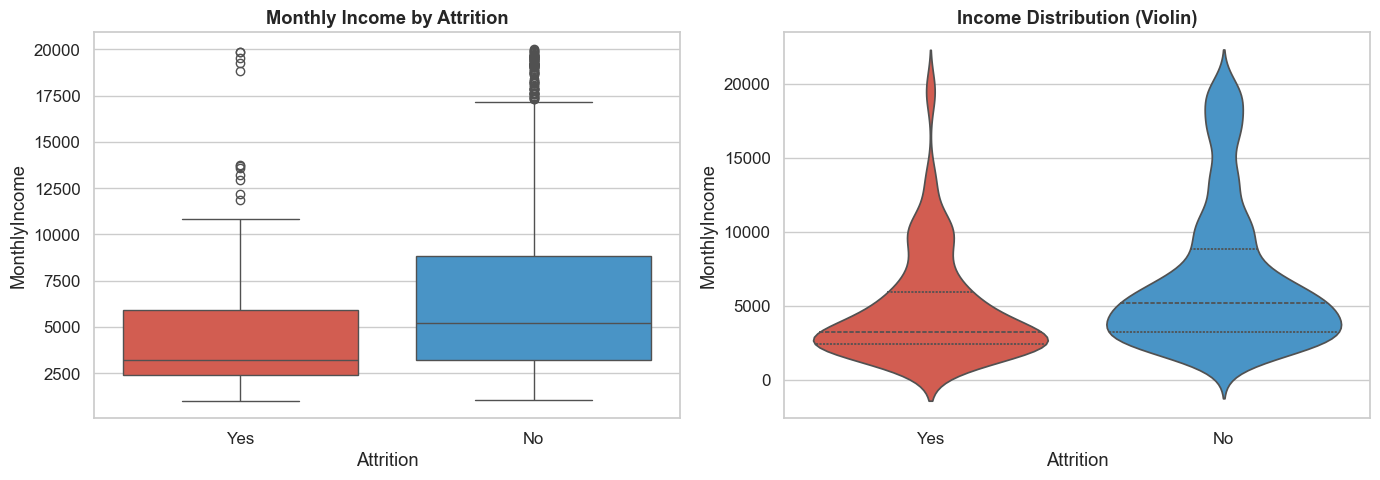

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6833.0,4818.0,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.0,3640.0,1009.0,2373.0,3202.0,5916.0,19859.0


In [34]:
fig , ax = plt.subplots(1,2,figsize=(14,5))

sns.boxplot(data=df,x='Attrition',y='MonthlyIncome',palette={"Yes": "#E74C3C", "No": "#3498DB"}, ax=ax[0])
ax[0].set_title("Monthly Income by Attrition", fontweight="bold")

sns.violinplot(data=df,x='Attrition',y='MonthlyIncome',palette={"Yes": "#E74C3C", "No": "#3498DB"}, inner="quartile", ax=ax[1])
ax[1].set_title("Income Distribution (Violin)", fontweight="bold")

plt.tight_layout()
plt.show()

df.groupby("Attrition")["MonthlyIncome"].describe().round(0)

**Finding:** Median income of leavers (3,200) is well below stayers (5,200). 
The leaver distribution is concentrated at the low end, while stayers have a long tail of high earners.
**Caveat:** Income is strongly tied to JobLevel and tenure, so low income here may partly reflect junior employees, not pay alone.

## 2.3 Tenure analysis - When Do People Leave?

,Employees,Leavers,Rate
Tenure_bucket,,,
0-1 yrs,215,75,34.88
2-5 yrs,561,87,15.51
6-10 yrs,448,55,12.28
10+ yrs,246,20,8.13


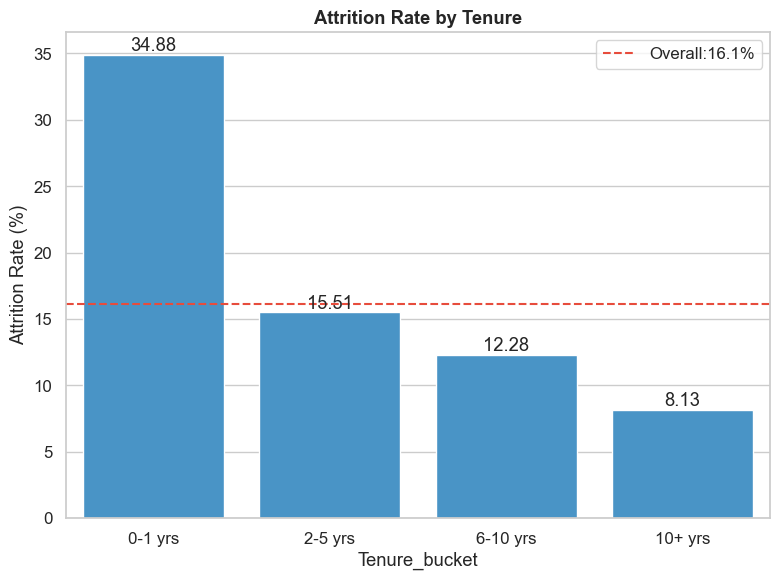

In [35]:
bins = [-1,1,5,10,df['YearsAtCompany'].max()]
labels = ["0-1 yrs", "2-5 yrs", "6-10 yrs", "10+ yrs"]

df['Tenure_bucket'] = pd.cut(df['YearsAtCompany'],bins=bins,labels=labels)

display(attrition_by('Tenure_bucket',df,order=labels))
plot_attrition_rate("Tenure_bucket",df,order=labels,title='Attrition Rate by Tenure')

**Finding:** Attrition is highest in the first year (~35%) and falls steadily with tenure.                                         
**Interpretation:** Early-tenure attrition points to onboarding, role-expectation or hiring-fit problems. 
Long-tenure attrition would point to growth stagnation or compensation.

# Phase 3: Statistical Testing
- Significance level: alpha = 0.05
- **H₀ :** the feature and attrition are independent | **H₁ :** they are related

In [36]:
from scipy.stats import chi2_contingency, ttest_ind, pointbiserialr
alpha = 0.05

## 3.1 Chi-square test (categorical vs Attrition)

In [37]:
cat_colm = ["OverTime", "Department", "JobRole", "MaritalStatus", "Gender", "EducationField","JobSatisfaction_Label"]

rows = []
for colm in cat_colm:
    table = pd.crosstab(df[colm],df['Attrition'])
    
    chi2 , p , dof , expected = chi2_contingency(table)
    n = table.values.sum()
    cramers_v = np.sqrt(chi2/(n*(min(table.shape)-1)))

    rows.append([colm,round(chi2,2), p, round(cramers_v,3),
                'significant' if p < alpha else 'not significant'])

chi_results = pd.DataFrame(rows,columns=['feature','chi2','p_value','cramers_v','result'])
chi_results.sort_values('p_value')

,feature,chi2,p_value,cramers_v,result
0,OverTime,87.56,8.158424e-21,0.244,significant
2,JobRole,86.19,2.752482e-15,0.242,significant
3,MaritalStatus,46.16,9.455511e-11,0.177,significant
6,JobSatisfaction_Label,17.51,5.563005e-04,0.109,significant
1,Department,10.80,4.525607e-03,0.086,significant
5,EducationField,16.02,6.773980e-03,0.104,significant
4,Gender,1.12,2.905724e-01,0.028,not significant


**Interpretation:** Overtime, job role and marital status are genuinely linked to attrition. The Gender gap seen earlier is within normal random variation, so gender is not a driver

## 3.2 Numeric features vs Attrition

In [38]:
num_colm = ["MonthlyIncome", "Age", "DistanceFromHome", "YearsAtCompany"] 

rows = []
for col in num_colm: 
    leaver = df.loc[df['Attrition']=='Yes',col]
    stayer = df.loc[df["Attrition"] == "No", col]

    t,p_t = ttest_ind(leaver,stayer,equal_var=False)
    r,p_r = pointbiserialr(df['Attrition_flag'],df[col])

    rows.append([col,round(leaver.mean(),2), round(stayer.mean(),1), round(t, 2), p_t, round(r, 3),
                 "significant" if p_t < alpha else "not significant"])

num_results = pd.DataFrame(rows, columns=["Feature", "Leaver", "Stayers","t-stat", "p-value", "point-biserial r", "result"])
num_results

,Feature,Leaver,Stayers,t-stat,p-value,point-biserial r,result
0,MonthlyIncome,4787.09,6832.7,-7.48,4.433589e-13,-0.160,significant
1,Age,33.61,37.6,-5.83,1.379760e-08,-0.159,significant
2,DistanceFromHome,10.63,8.9,2.89,4.136512e-03,0.078,significant
3,YearsAtCompany,5.13,7.4,-5.28,2.285905e-07,-0.134,significant


**Interpretation:** Leavers are on average younger, lower-paid and shorter-tenured. 
All correlations are weak individually (|r| < 0.2), which means attrition is driven by a combination of factors.

## 3.3 Correlation Heatmap

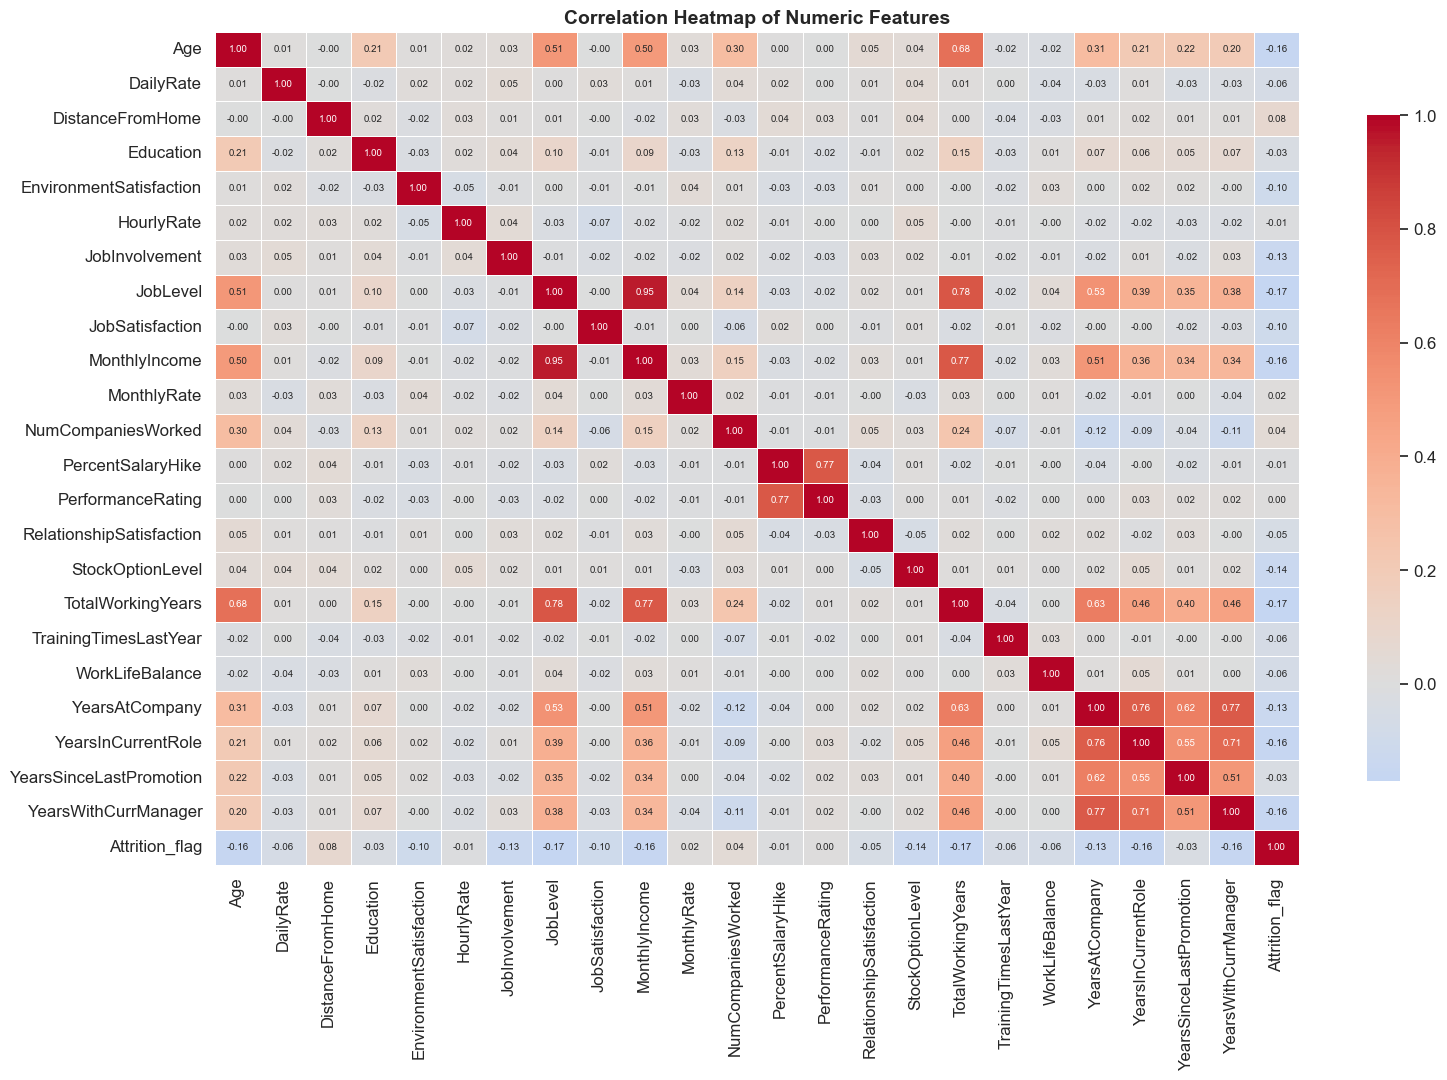

In [39]:
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()


plt.figure(figsize=(16, 11))
sns.heatmap(corr,cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Multicollinearity:** MonthlyIncome, JobLevel and TotalWorkingYears are highly correlated (r > 0.7). They largely measure the same thing (seniority), so their individual effects on attrition should not be interpreted separately.                                                                         
**Tenure cluster:** YearsAtCompany, YearsInCurrentRole and YearsWithCurrManager move together.                                                         
**Link to attrition:** No numeric feature has a strong linear correlation with attrition (all |r| < 0.2), again pointing to combined effects.

## Executive Summary

**Key findings**
1. **Overtime is the strongest driver:** overtime employees leave at ~30% vs ~10% (p < 0.001).
2. **Role matters:** Sales Representatives have the highest attrition of any job role.
3. **Single employees** leave at ~25%, versus much lower rates for married and divorced employees.
4. **Early tenure is risky:** attrition is highest among newer employees.
5. **Leavers are younger and lower-paid:** on average ~4 years younger and ~30% lower monthly income.
6. **Gender is not a driver:** the 17% vs 14.8% gap is not statistically significant (p = 0.29).

**Top recommendation:** Start with a workload audit for overtime-heavy roles and an early-tenure retention programme for new hires.

### Limitations
- **Association, not causation:** These tests show which factors are linked to attrition, not that they cause it. For example, overtime may be a symptom of a deeper problem like understaffing.
- **Income is confounded:** Income is tied to job level and experience, so low pay among leavers partly reflects junior roles.
- **Small groups:** Some segments (e.g. Human Resources education field) have few employees, so their rates are unstable.
- **Single snapshot:** The dataset is one point in time. We cannot see trends, and the data is a well-known sample dataset, not a live company's.
- **No predictive model:** This project explains attrition; it does not predict individual employees. Logistic Regression or Random Forest would be a natural next step.

### Conclusion
Attrition in this dataset is not random. It is concentrated among overtime workers, specific roles (notably Sales Representatives), single employees and early-tenure staff. 
No single factor explains attrition on its own, so HR should combine targeted actions (workload, onboarding, role-specific reviews) rather than one company-wide fix.

------------------------------------------------------------------------------------------------------------------------------------------------------                            